# Assignment 1: Discrete Fourier Transform (DFT) and Short-Time Fourier Transform (STFT)

<hr>

- Name: Tony Callaghan
- Student Number: 20739321

<hr>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import time

Task 1: Discrete Fourier Transform (DFT)

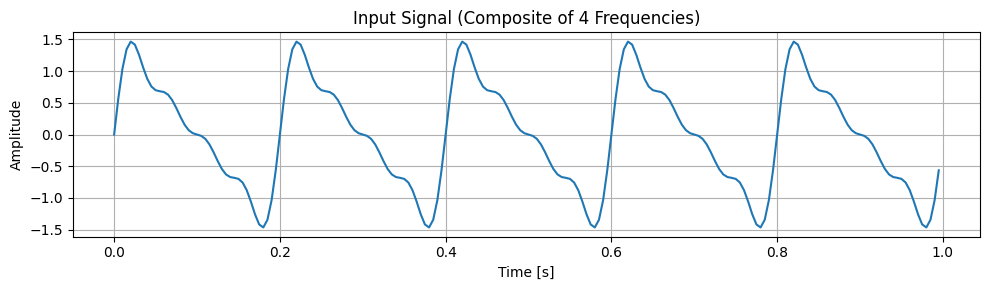

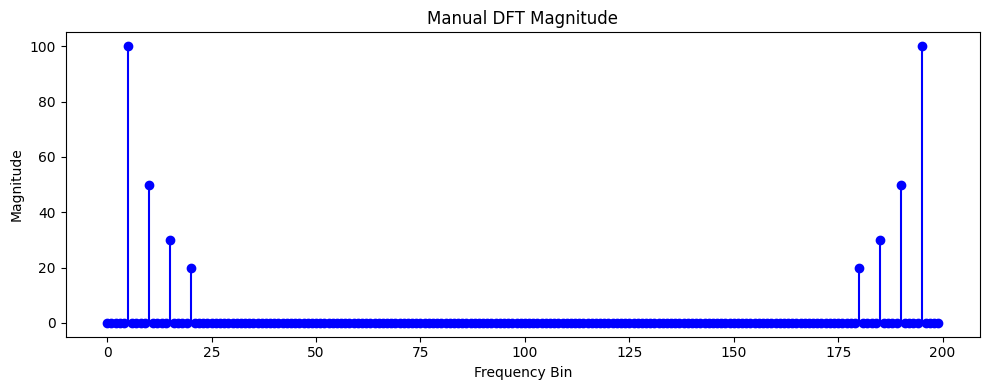

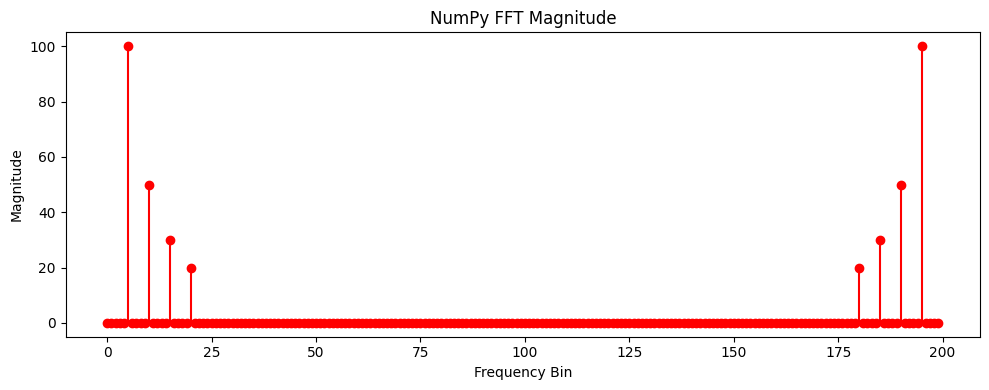

Manual DFT time: 0.007288 seconds
NumPy FFT time:  0.000211 seconds
Max absolute error: 1.183331e-12


In [39]:
# Set the sample rate and duration
sampleRate = 200
sec = 1

# Calculate the number of samples
N = sampleRate * sec

# Create an array to store the samples
sample = np.zeros(N)
t = np.linspace(0, sec, N, endpoint=False)

# Set the frequency of the input signal
sampleFreq = 5

# Set the initial phase of the input signal
phase = 0

# Generate composite signal (fundamental + 3 harmonics)
sample = (np.sin(phase + 2 * np.pi * sampleFreq * t) +
          0.5 * np.sin(phase + 2 * np.pi * 2 * sampleFreq * t) +
          0.3 * np.sin(phase + 2 * np.pi * 3 * sampleFreq * t) +
          0.2 * np.sin(phase + 2 * np.pi * 4 * sampleFreq * t))

# Plot input signal
figure, axis = plt.subplots(1, figsize=(10, 3))
axis.plot(t, sample)
axis.set_title("Input Signal (Composite of 4 Frequencies)")
axis.set_xlabel("Time [s]")
axis.set_ylabel("Amplitude")
axis.grid(True)
plt.tight_layout()
plt.show()

# Manual DFT via matrix multiplication
n = np.arange(N)                          # time indices
k = np.arange(N)                          # freq indices
W = np.exp(-2j * np.pi * np.outer(k, n) / N)  # DFT matrix (N x N)

startManual = time.time()                # start timer
X_manual = W.dot(sample)                 # apply DFT manually
endManual = time.time()                  # end timer
manualTime = endManual - startManual     # calc duration

# NumPy FFT
startFFT = time.time()                   # start timer
X_fft = np.fft.fft(sample)               # built-in FFT
endFFT = time.time()                     # end timer
fftTime = endFFT - startFFT              # calc duration

# Plot Manual DFT Magnitude
figure, axis = plt.subplots(1, figsize=(10, 4))
axis.stem(np.arange(N), np.abs(X_manual), basefmt=" ", linefmt="blue", markerfmt="bo")
axis.set_title("Manual DFT Magnitude")
axis.set_xlabel("Frequency Bin")
axis.set_ylabel("Magnitude")
axis.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# Plot NumPy FFT Magnitude
figure, axis = plt.subplots(1, figsize=(10, 4))
axis.stem(np.arange(N), np.abs(X_fft), basefmt=" ", linefmt="red", markerfmt="ro")
axis.set_title("NumPy FFT Magnitude")
axis.set_xlabel("Frequency Bin")
axis.set_ylabel("Magnitude")
axis.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

# Print timings and max error
maxError = np.max(np.abs(X_manual - X_fft))
print(f"Manual DFT time: {manualTime:.6f} seconds")
print(f"NumPy FFT time:  {fftTime:.6f} seconds")
print(f"Max absolute error: {maxError:.6e}")


Task 2: Short-Time Fourier Transform (STFT)

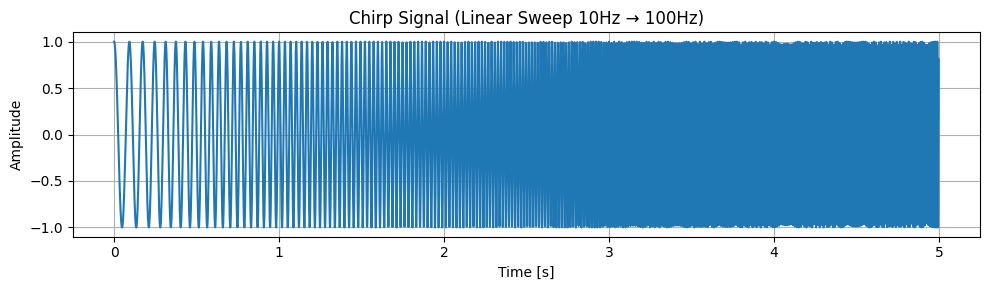

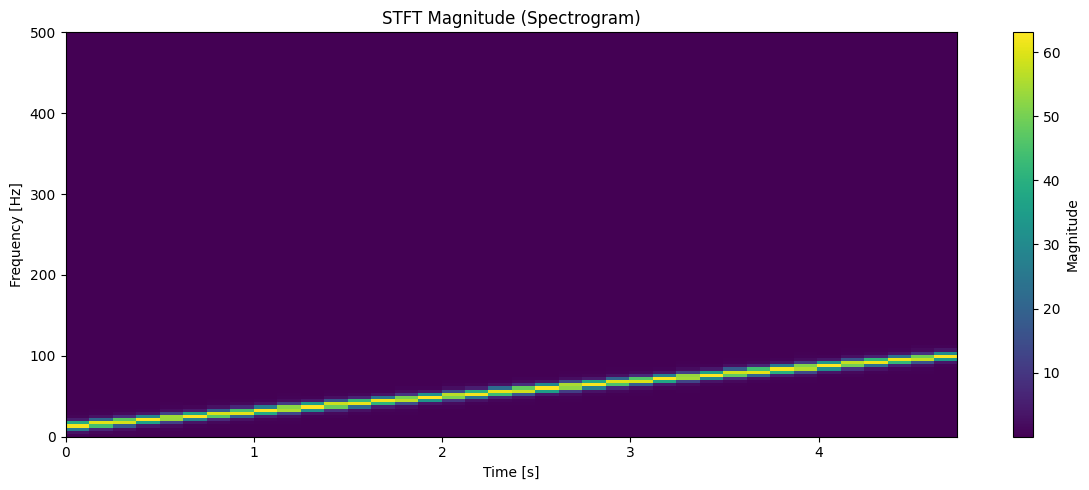

In [38]:
from scipy.signal import chirp

# Set the sample rate and duration
sampleRate = 1000
sec = 5

# Calculate the number of samples
N = sampleRate * sec

# Create an array of time points
t = np.linspace(0, sec, N, endpoint=False)

# Generate chirp signal (sweep from 10 Hz to 100 Hz)
sample = chirp(t, f0=10, f1=100, t1=sec, method='linear')

# --- Plot input chirp signal ---
figure, axis = plt.subplots(1, figsize=(10, 3))
axis.plot(t, sample)
axis.set_title("Chirp Signal (Linear Sweep 10Hz → 100Hz)")
axis.set_xlabel("Time [s]")
axis.set_ylabel("Amplitude")
axis.grid(True)
plt.tight_layout()
plt.show()

# Set STFT parameters
winSize = 256                      # samples per window
hopSize = winSize // 2            # overlap 50%
window = np.hanning(winSize)      # Hanning window
numFrames = (N - winSize) // hopSize + 1

# Create an array to store the STFT magnitudes
stftMag = np.zeros((winSize // 2, numFrames))

# STFT O(n)
for i in range(numFrames):
    start = i * hopSize
    end = start + winSize

    frame = sample[start:end]             # extract frame
    windowed = frame * window             # apply window
    spectrum = np.fft.fft(windowed)       # compute FFT
    mag = np.abs(spectrum[:winSize // 2]) # keep positive freqs only

    stftMag[:, i] = mag                   # store mag spectrum

# Calculate time and frequency axes
timeAxis = np.arange(numFrames) * hopSize / sampleRate
freqAxis = np.linspace(0, sampleRate / 2, winSize // 2)

# Plot STFT magnitude as a spectrogram
plt.figure(figsize=(12, 5))
plt.imshow(stftMag,
           aspect='auto',
           origin='lower',
           extent=[timeAxis[0], timeAxis[-1], freqAxis[0], freqAxis[-1]],
           cmap='viridis')
plt.colorbar(label='Magnitude')
plt.title("STFT Magnitude (Spectrogram)")
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.tight_layout()
plt.show()
